# CLASSIFICATION WITH SHAPELETS + shapelets analysis

In [1]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from tslearn.shapelets import ShapeletModel, grabocka_params_to_shapelet_size_dict
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")
X_train = X_train.iloc[:, :100]
X_test = X_test.iloc[:, :100]
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [ ]:
# scaler_ts = MinMaxScaler()
# X_train_scaled = scaler_ts.fit_transform(X_train)
# X_test_scaled = scaler_ts.transform(X_test)

In [4]:
# Calcola shapelet_sizes con la funzione grabocka_params_to_shapelet_size_dict
shapelet_sizes = grabocka_params_to_shapelet_size_dict(
    n_ts=X_train.shape[0],
    ts_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    l=0.1,    # lunghezza media shapelet = 10% della serie temporale
    r=10      # shapelet per classe
)

print("Shapelet sizes dict:", shapelet_sizes)


Shapelet sizes dict: {10: 5, 20: 5, 30: 5, 40: 5, 50: 5, 60: 5, 70: 4, 80: 4, 90: 4, 100: 3}


In [5]:
shp_model = ShapeletModel(
    n_shapelets_per_size=shapelet_sizes,
    optimizer='adam',
    weight_regularizer=0.01,
    max_iter=100,
    random_state=42,
    verbose=1
)

shp_model.fit(X_train, y_train)
X_shp_train = shp_model.transform(X_train)
X_shp_test = shp_model.transform(X_test)

c:\Users\Gagia\anaconda3\Lib\site-packages\tslearn\shapelets\shapelets.py:353: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - categorical_accuracy: 0.2043 - categorical_crossentropy: 1.9209 - loss: 2.0036
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - categorical_accuracy: 0.2043 - categorical_crossentropy: 1.8565 - loss: 1.9387
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - categorical_accuracy: 0.2043 - categorical_crossentropy: 1.7958 - loss: 1.8777
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - categorical_accuracy: 0.2093 - categorical_crossentropy: 1.7391 - loss: 1.8207
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - categorical_accuracy: 0.2119 - categorical_crossentropy: 1.6866 - loss: 1.7679
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - categorical_accuracy: 0.2245 - categorical_crossentropy: 1.6385 - loss: 1.7196
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - categorical_accuracy: 0.2333 - categorical_crossentropy: 1.5949 - loss: 1.6756
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - categorical_accuracy: 0.2484 - 

In [6]:
# Addestra RandomForest SENZA TUNING
rf = RandomForestClassifier(random_state=42)
rf.fit(X_shp_train, y_train)

# Predizione
y_pred = rf.predict(X_shp_test)

# Valutazione
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.44      0.18      0.25        39
         2.0       0.43      0.63      0.51       116
         3.0       0.25      0.10      0.14        70
         4.0       0.54      0.61      0.57       113

    accuracy                           0.46       341
   macro avg       0.33      0.30      0.30       341
weighted avg       0.43      0.46      0.42       341



c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
#PARAMETRI DA GRIDSEARCH
clf = RandomForestClassifier(criterion= 'gini', max_depth= 10, max_features= 'log2', min_samples_leaf=2, 
                             min_samples_split= 10, n_estimators= 100, random_state=42,  class_weight='balanced')
clf.fit(X_shp_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       max_features='log2', min_samples_leaf=2,
                       min_samples_split=10, random_state=42)

In [8]:
y_pred_tr = clf.predict(X_shp_train)
print("train CR")
print(classification_report(y_train, y_pred_tr))

train CR
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         7
         1.0       0.87      0.94      0.90        89
         2.0       0.85      0.93      0.89       271
         3.0       0.95      0.93      0.94       162
         4.0       0.94      0.83      0.88       264

    accuracy                           0.90       793
   macro avg       0.92      0.93      0.92       793
weighted avg       0.90      0.90      0.90       793



In [9]:
y_pred_ts = clf.predict(X_shp_test)
print("test CR")
print(classification_report(y_test, y_pred_ts))

test CR
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.28      0.21      0.24        39
         2.0       0.41      0.59      0.48       116
         3.0       0.24      0.11      0.15        70
         4.0       0.61      0.58      0.59       113

    accuracy                           0.44       341
   macro avg       0.30      0.30      0.29       341
weighted avg       0.42      0.44      0.42       341



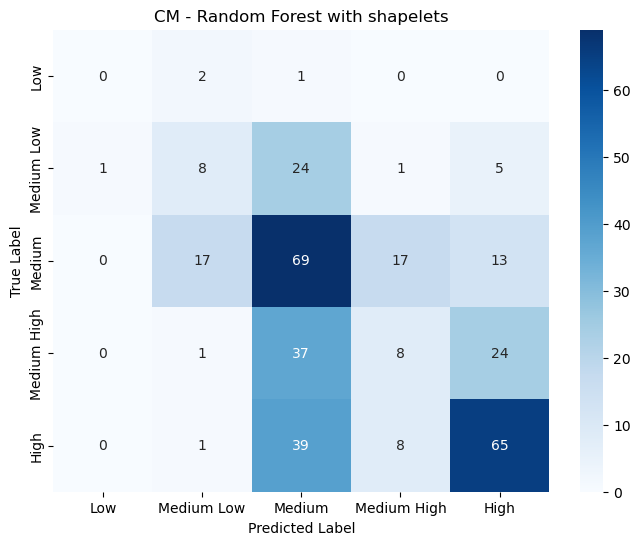

In [10]:
from sklearn.metrics import confusion_matrix

# Calcola la confusion matrix
cm = confusion_matrix(y_test, y_pred_ts)

labels = ["Low", "Medium Low", "Medium", "Medium High", "High"]

# Visualizza con heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CM - Random Forest with shapelets')
plt.show()

In [14]:
import joblib

# Salva il modello
joblib.dump(shp_model, "shp_model.pkl")

# Salva anche le trasformazioni se vuoi
joblib.dump(X_shp_train, "X_shp_train.pkl")
joblib.dump(X_shp_test, "X_shp_test.pkl")

['X_shp_test.pkl']

In [15]:
import numpy as np

# Estrai le shapelet dal modello
shapelets = shp_model.shapelets_as_time_series_

# Salva in un file .npy
np.save("shapelets.npy", shapelets)


<!-- ### Analisi shapelets -->

### Analisi shapelets vs motifs

In [11]:
importances = clf.feature_importances_
importances

array([0.03700058, 0.02968896, 0.02529474, 0.01810568, 0.02994854,
       0.02311856, 0.02091356, 0.02308716, 0.02645299, 0.04332455,
       0.0242731 , 0.0211158 , 0.02932381, 0.01728813, 0.01856137,
       0.01965488, 0.02130948, 0.02019634, 0.02353157, 0.02661076,
       0.01173399, 0.02267259, 0.01754801, 0.01737046, 0.02453753,
       0.02209221, 0.02243718, 0.02232293, 0.01348096, 0.01629467,
       0.01778936, 0.01669857, 0.01616382, 0.01992116, 0.02504219,
       0.01785981, 0.01677683, 0.02394295, 0.01287546, 0.01599368,
       0.0245024 , 0.02977285, 0.01640428, 0.0301079 , 0.02685767])

In [12]:
indices = np.argsort(importances)[::-1]

# Stampa le prime 10 più importanti
for i in range(10):
    print(f"Shapelet {indices[i]} - Importance: {importances[indices[i]]:.4f}")

Shapelet 9 - Importance: 0.0433
Shapelet 0 - Importance: 0.0370
Shapelet 43 - Importance: 0.0301
Shapelet 4 - Importance: 0.0299
Shapelet 41 - Importance: 0.0298
Shapelet 1 - Importance: 0.0297
Shapelet 12 - Importance: 0.0293
Shapelet 44 - Importance: 0.0269
Shapelet 19 - Importance: 0.0266
Shapelet 8 - Importance: 0.0265


In [13]:
import numpy as np

# X_shp_train.shape = (n_samples, n_shapelets)
shapelet_idx = 0  # esempio
mean_dist_per_class = []
for c in np.unique(y_train):
    mean_dist_per_class.append(np.mean(X_shp_train[y_train==c, shapelet_idx]))
    
print(mean_dist_per_class)


[0.0014485361, 0.0040919553, 0.004135873, 0.008495569, 0.015228514]


In [14]:
import numpy as np

# X_shp_train.shape = (n_samples, n_shapelets)
# y_train.shape = (n_samples,)

result = {}

for c in np.unique(y_train):
    mean_dists = []
    for shapelet_idx in range(X_shp_train.shape[1]):
        mean_val = np.mean(X_shp_train[y_train == c, shapelet_idx])
        mean_dists.append((shapelet_idx, mean_val))
    
    # ordino per distanza media crescente
    mean_dists.sort(key=lambda x: x[1])
    
    # prendo i primi 3 indici
    top3 = [idx for idx, _ in mean_dists[:3]]
    
    result[c] = top3

print(result)


{0.0: [0, 21, 15], 1.0: [0, 15, 21], 2.0: [0, 15, 5], 3.0: [0, 3, 5], 4.0: [0, 3, 5]}


In [15]:
shapelets = shp_model.shapelets_as_time_series_
shape = shapelets[0]
shape_clean = shape[~np.isnan(shape)]
shape_clean

array([-0.48711625, -0.45971254, -0.43719172, -0.49496168, -0.52197438,
       -0.54215765, -0.54671437, -0.52754575, -0.52494168, -0.52008039])

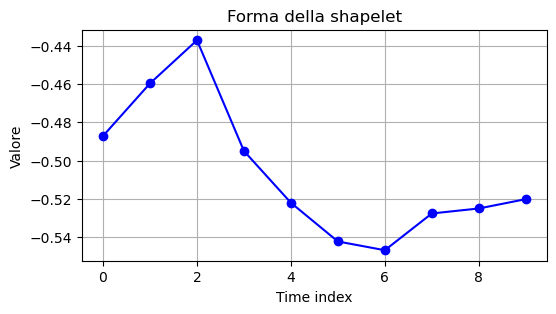

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# esempio: shapelet con NaN come quella che hai mostrato
shape = np.array([
    0.10409354, 0.02839074, 0.37553555, 0.31767145, 0.08694325,
    0.02425086, 0.33711153, 0.36105978, 0.12870429, 0.12011517
])

# rimuovo i NaN
# shape_clean = shape[~np.isnan(shape)]

# creo l'asse temporale (lunghezza della shapelet)
time_axis = np.arange(len(shape_clean))

# plot
plt.figure(figsize=(6,3))
plt.plot(time_axis, shape_clean, marker="o", linestyle="-", color="b")
plt.title("Forma della shapelet")
plt.xlabel("Time index")
plt.ylabel("Valore")
plt.grid(True)
plt.show()


In [17]:
for c in np.unique(y_train):
    mean_dists = []
    for shapelet_idx in range(X_shp_train.shape[1]):
        mean_val = np.mean(X_shp_train[y_train == c, shapelet_idx])
        mean_dists.append((shapelet_idx, mean_val))
    
    mean_dists.sort(key=lambda x: x[1])
    print(f"Classe {c}: top 5 -> {mean_dists[:5]}")

Classe 0.0: top 5 -> [(0, 0.0014485361), (21, 0.009414084), (15, 0.009620694), (27, 0.011046996), (5, 0.01365975)]
Classe 1.0: top 5 -> [(0, 0.0040919553), (15, 0.013259037), (21, 0.015398518), (5, 0.015690785), (27, 0.022663992)]
Classe 2.0: top 5 -> [(0, 0.004135873), (15, 0.016215526), (5, 0.018970931), (21, 0.020615324), (3, 0.022801861)]
Classe 3.0: top 5 -> [(0, 0.008495569), (3, 0.028369192), (5, 0.030025141), (7, 0.038664937), (15, 0.04331602)]
Classe 4.0: top 5 -> [(0, 0.015228514), (3, 0.031855628), (5, 0.041034237), (1, 0.047953535), (7, 0.053947765)]


In [18]:
shapelets = shp_model.shapelets_as_time_series_

Top 3 shapelets uniche per classe 1: [0, 15, 21]


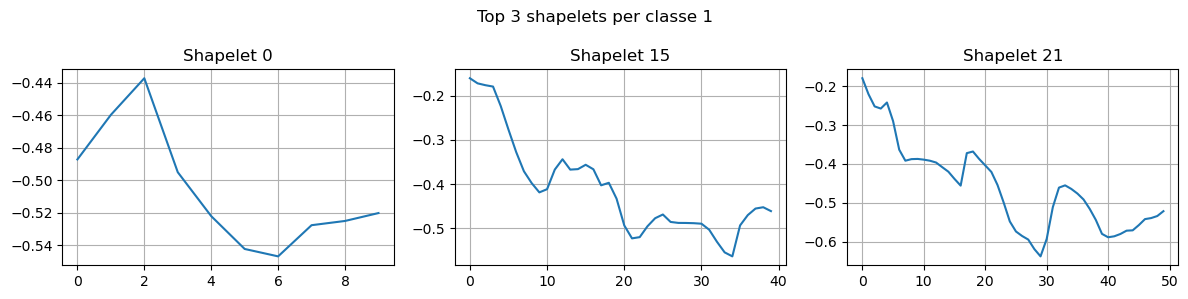

Top 3 shapelets uniche per classe 2: [5, 3, 12]


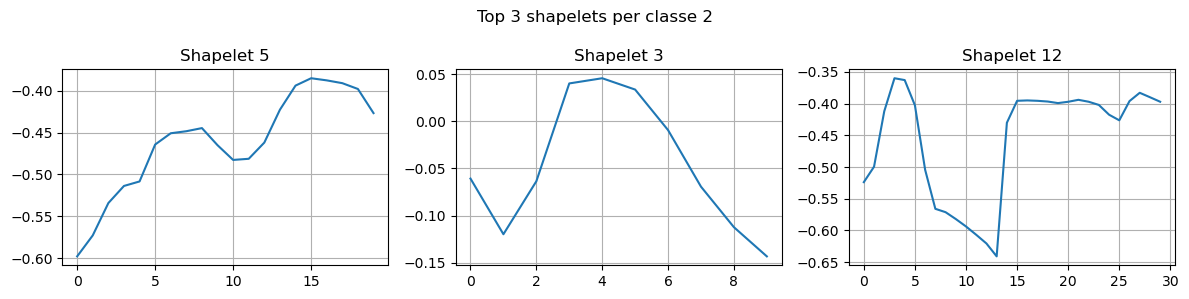

Top 3 shapelets uniche per classe 3: [7, 1, 11]


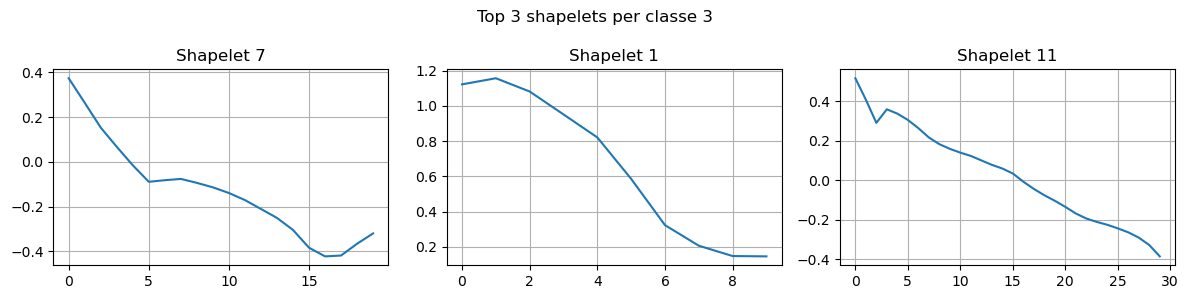

Top 3 shapelets uniche per classe 4: [13, 17, 2]


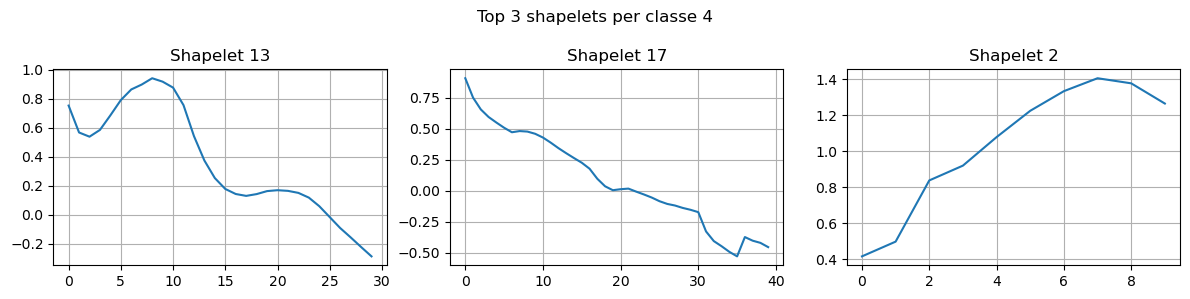

c:\Users\Gagia\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Gagia\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Top 3 shapelets uniche per classe 5: [24, 25, 26]


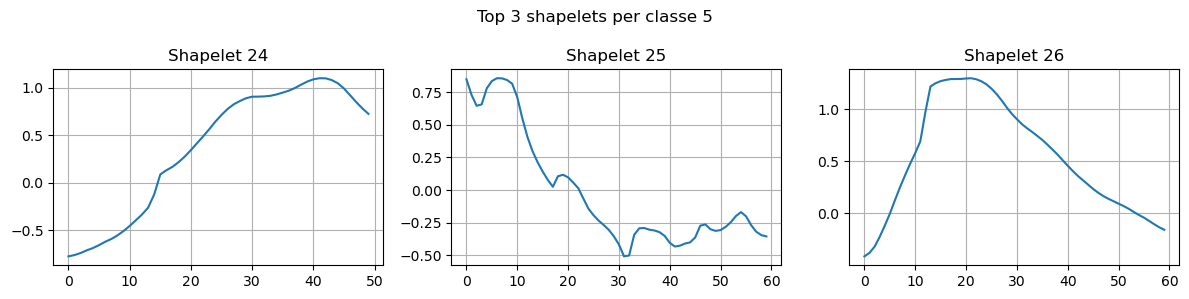

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Lista per tenere traccia delle shapelet già assegnate
used_shapelets = set()

# Ciclo sulle classi
for class_idx in range(1, 6):  # classi da 1 a 5
    # media delle distanze shapelet/class
    mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) for i in range(X_shp_train.shape[1])])

    # ordina gli indici delle shapelet in base alla distanza media
    sorted_idx = np.argsort(mean_dists)

    # seleziona le prime 3 shapelet non ancora usate
    topk_idx = []
    for idx in sorted_idx:
        if idx not in used_shapelets:
            topk_idx.append(idx)
            used_shapelets.add(idx)
        if len(topk_idx) >= 3:
            break

    print(f"Top 3 shapelets uniche per classe {class_idx}: {topk_idx}")

    # plot delle top 3 shapelet
    plt.figure(figsize=(12, 3))
    for j, shp_idx in enumerate(topk_idx):
        plt.subplot(1, 3, j+1)
        plt.plot(shapelets[shp_idx])
        plt.title(f"Shapelet {shp_idx}")
        plt.grid(True)
    plt.suptitle(f"Top 3 shapelets per classe {class_idx}")
    plt.tight_layout()
    plt.show()



##### più giusto ma restituisce nan per distanza

<!-- #### con stumpy -->

In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# import stumpy
# from dtaidistance import dtw

# # Supponiamo di avere già:
# # X_train_scaled: array delle serie temporali scalate
# # y_train: array delle etichette
# # X_shp_train: distanze shapelet vs serie temporali
# # shapelets: lista di shapelet estratte

# def top_k_shapelets_per_class_func(X_shp_train, y_train, topk=3):
#     """Calcola le top-k shapelet uniche per classe"""
#     used_shapelets = set()
#     all_topk = []
#     for class_idx in range(1, 6):  # classi 1-5
#         mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) 
#                                for i in range(X_shp_train.shape[1])])
#         sorted_idx = np.argsort(mean_dists)
        
#         topk_idx = []
#         for idx in sorted_idx:
#             if idx not in used_shapelets:
#                 topk_idx.append(idx)
#                 used_shapelets.add(idx)
#             if len(topk_idx) >= topk:
#                 break
#         all_topk.append(topk_idx)
#     return all_topk

# # Calcolo top 3 shapelet per classe
# topk_shapelets_per_class = top_k_shapelets_per_class_func(X_shp_train, y_train, topk=3)

# # Loop su ciascuna classe
# for class_idx in np.unique(y_train):
#     print(f"\n=== Classe {class_idx} ===")
    
#     # Seleziona le serie della classe
#     X_class = X_train_scaled[y_train == class_idx]
    
#     # Lunghezza dei motif = lunghezza della shapelet più rappresentativa della classe
#     motif_len = shapelets[int(topk_shapelets_per_class[int(class_idx)-1][0])].shape[0]
    
#     # Concatenazione delle serie
#     ts_concat = np.concatenate(X_class)
    
#     # Calcolo matrix profile con STUMP
#     mp = stumpy.stump(ts_concat, m=motif_len)
    
#     # Estrarre top 3 motif: indici dei valori minimi del matrix profile
#     top3_motif_idx = np.argsort(mp[:, 0])[:3]
#     print(f"Top 3 motif start indices: {top3_motif_idx}")
    
#     # Confronto DTW shapelet vs motif
#     for shp_idx in topk_shapelets_per_class[int(class_idx)-1]:
#         shp_idx = int(shp_idx)
#         shp = shapelets[shp_idx]
#         print(f"\nShapelet {shp_idx}:")
        
#         for motif_start in top3_motif_idx:
#             motif = ts_concat[motif_start:motif_start+motif_len]
#             distance = dtw.distance(shp, motif)
#             print(f"DTW distance to motif starting at {motif_start}: {distance:.3f}")
            
#             # Plot confronto
#             plt.figure(figsize=(6,3))
#             plt.plot(shp, label='Shapelet')
#             plt.plot(motif, label='Motif')
#             plt.title(f"Classe {class_idx} - Shapelet {shp_idx} vs Motif {motif_start}")
#             plt.legend()
#             plt.show()


##### fill con 0

In [26]:
# import numpy as np
# import matplotlib.pyplot as plt
# import stumpy
# from dtaidistance import dtw

# # Supponiamo di avere già:
# # X_train_scaled: array delle serie temporali scalate
# # y_train: array delle etichette
# # X_shp_train: distanze shapelet vs serie temporali
# # shapelets: lista di shapelet estratte

# def top_k_shapelets_per_class_func(X_shp_train, y_train, topk=3):
#     """Calcola le top-k shapelet uniche per classe"""
#     used_shapelets = set()
#     all_topk = []
#     for class_idx in range(1, 6):  # classi 1-5
#         mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) 
#                                for i in range(X_shp_train.shape[1])])
#         sorted_idx = np.argsort(mean_dists)
        
#         topk_idx = []
#         for idx in sorted_idx:
#             if idx not in used_shapelets:
#                 topk_idx.append(idx)
#                 used_shapelets.add(idx)
#             if len(topk_idx) >= topk:
#                 break
#         all_topk.append(topk_idx)
#     return all_topk

# # Calcolo top 3 shapelet per classe
# topk_shapelets_per_class = top_k_shapelets_per_class_func(X_shp_train, y_train, topk=3)

# # Loop su ciascuna classe
# for class_idx in np.unique(y_train):
#     print(f"\n=== Classe {class_idx} ===")
    
#     # Seleziona le serie della classe
#     X_class = X_train_scaled[y_train == class_idx]
    
#     # Lunghezza dei motif = lunghezza della shapelet più rappresentativa della classe
#     motif_len = shapelets[int(topk_shapelets_per_class[int(class_idx)-1][0])].shape[0]
    
#     # Concatenazione delle serie
#     ts_concat = np.concatenate(X_class)
    
#     # Calcolo matrix profile con STUMP
#     mp = stumpy.stump(ts_concat, m=motif_len)
    
#     # Estrarre top 3 motif basati sui valori minimi del matrix profile
#     top3_motif_idx = np.argsort(mp[:, 0])[:3]
#     print(f"Top 3 motif start indices: {top3_motif_idx}")
    
#     # Confronto DTW shapelet vs motif
#     for shp_idx in topk_shapelets_per_class[int(class_idx)-1]:
#         shp_idx = int(shp_idx)
#         shp = shapelets[shp_idx]
        
#         # Sostituisci eventuali NaN o Inf nella shapelet
#         shp = np.nan_to_num(shp)
        
#         print(f"\nShapelet {shp_idx}:")
#         for motif_start in top3_motif_idx:
#             motif = ts_concat[motif_start:motif_start+motif_len]
            
#             # Controllo lunghezza motif
#             if len(motif) != motif_len:
#                 print(f"Skipping motif at {motif_start} due to incorrect length")
#                 continue
            
#             # Sostituisci NaN o Inf nel motif
#             motif = np.nan_to_num(motif)
            
#             # Calcolo distanza DTW
#             distance = dtw.distance(shp, motif)
#             print(f"DTW distance to motif starting at {motif_start}: {distance:.3f}")
            
#             # Plot confronto
#             plt.figure(figsize=(6,3))
#             plt.plot(shp, label='Shapelet')
#             plt.plot(motif, label='Motif')
#             plt.title(f"Classe {class_idx} - Shapelet {shp_idx} vs Motif {motif_start}")
#             plt.legend()
#             plt.show()



=== Classe 0.0 ===


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x000002072C4D0EA0>
Traceback (most recent call last):
  File "c:\Users\Gagia\anaconda3\Lib\site-packages\llvmlite\binding\executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


Top 3 motif start indices (più frequenti): [155, 455, 156]

Shapelet 17:
DTW distance to motif starting at 155: nan


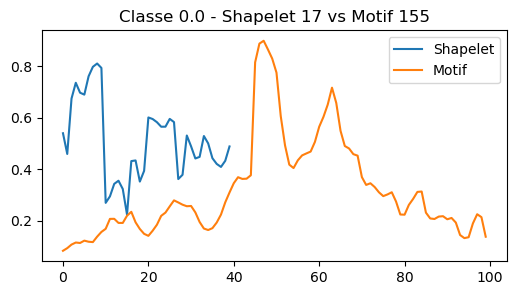

DTW distance to motif starting at 455: nan


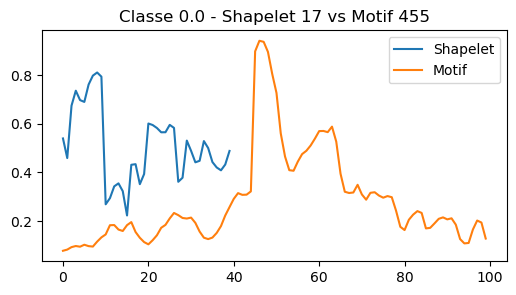

DTW distance to motif starting at 156: nan


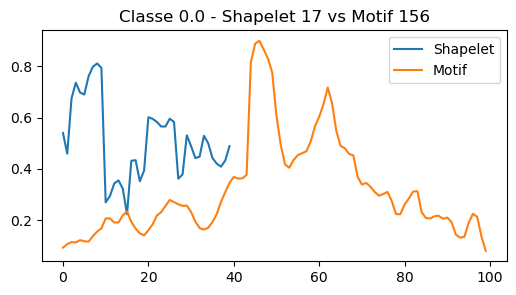


Shapelet 11:
DTW distance to motif starting at 155: nan


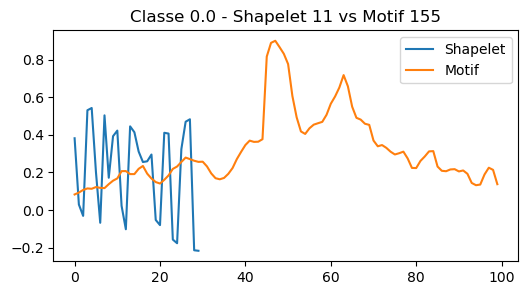

DTW distance to motif starting at 455: nan


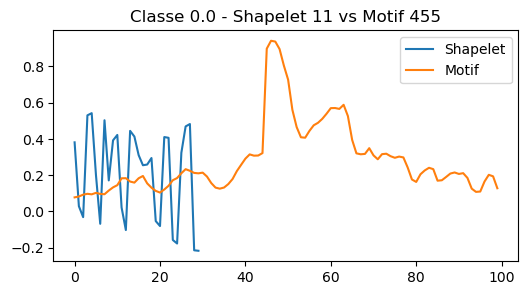

DTW distance to motif starting at 156: nan


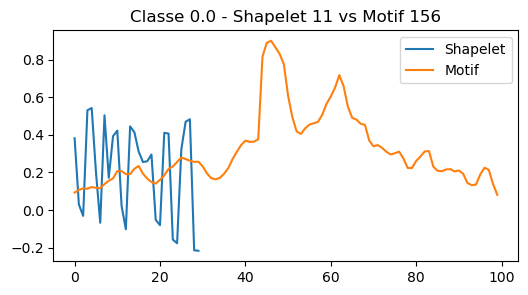


Shapelet 9:
DTW distance to motif starting at 155: nan


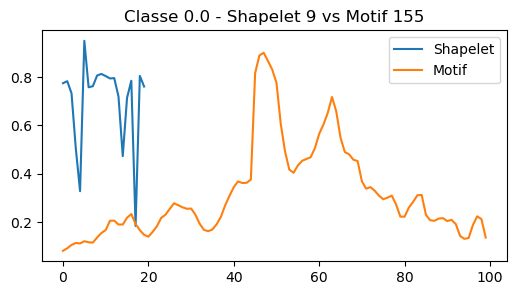

DTW distance to motif starting at 455: nan


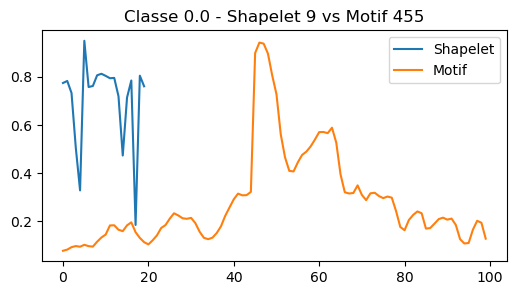

DTW distance to motif starting at 156: nan


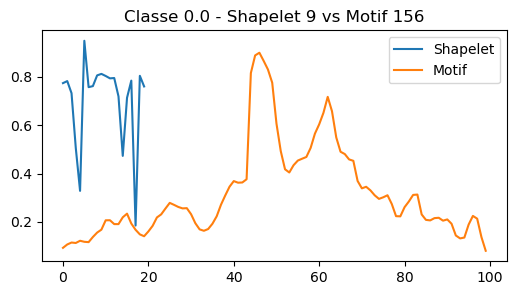


=== Classe 1.0 ===
Top 3 motif start indices (più frequenti): [4400, 800, 801]

Shapelet 3:
DTW distance to motif starting at 4400: nan


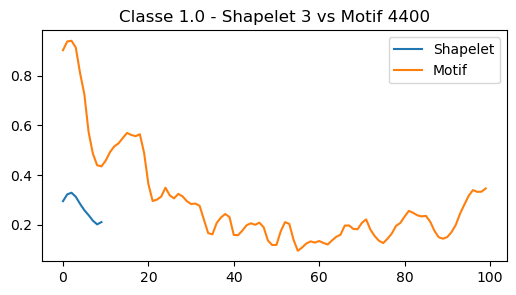

DTW distance to motif starting at 800: nan


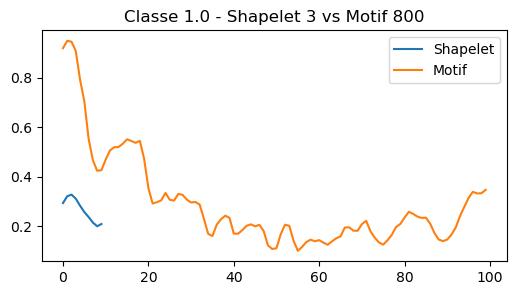

DTW distance to motif starting at 801: nan


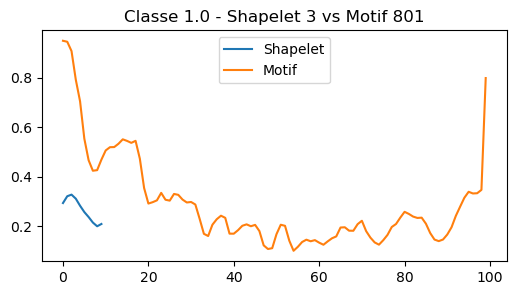


Shapelet 30:
DTW distance to motif starting at 4400: nan


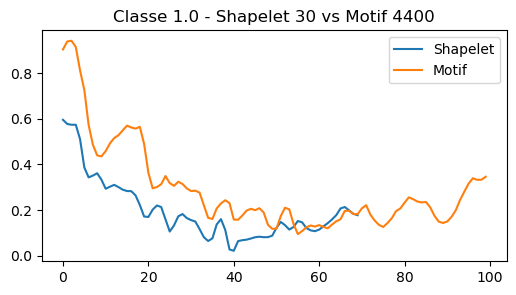

DTW distance to motif starting at 800: nan


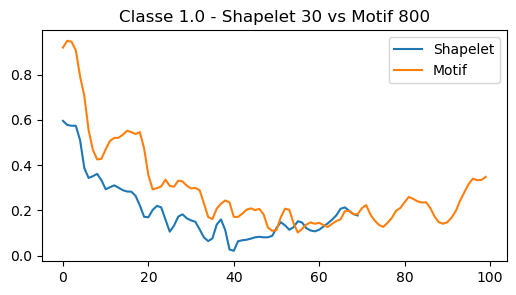

DTW distance to motif starting at 801: nan


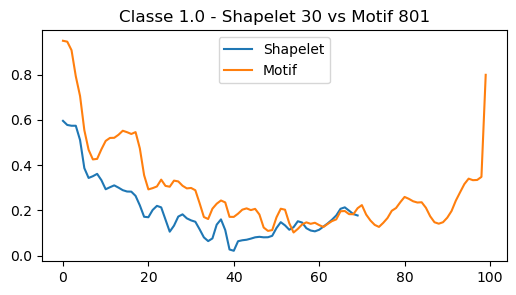


Shapelet 14:
DTW distance to motif starting at 4400: nan


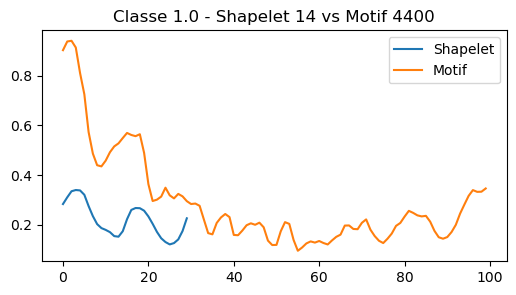

DTW distance to motif starting at 800: nan


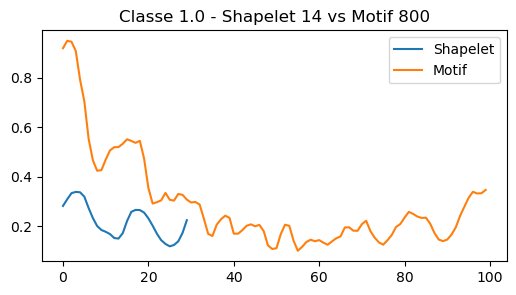

DTW distance to motif starting at 801: nan


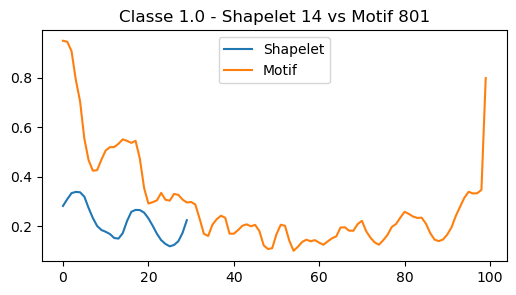


=== Classe 2.0 ===
Top 3 motif start indices (più frequenti): [3900, 6500, 3901]

Shapelet 1:
DTW distance to motif starting at 3900: nan


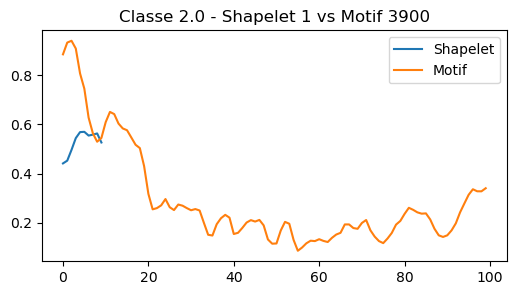

DTW distance to motif starting at 6500: nan


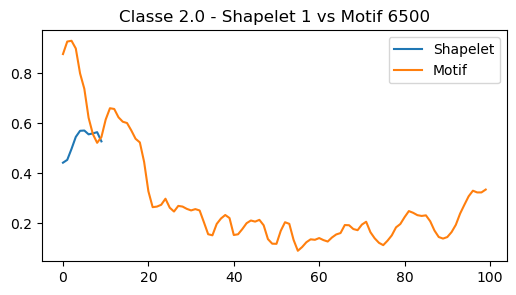

DTW distance to motif starting at 3901: nan


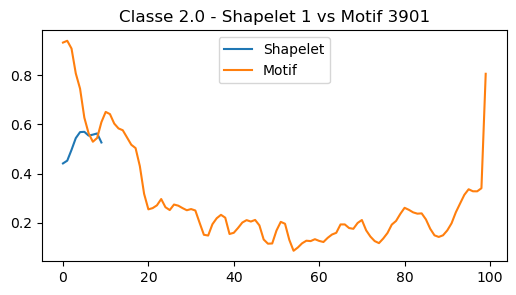


Shapelet 0:
DTW distance to motif starting at 3900: nan


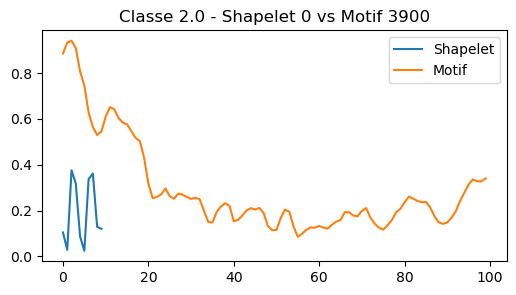

DTW distance to motif starting at 6500: nan


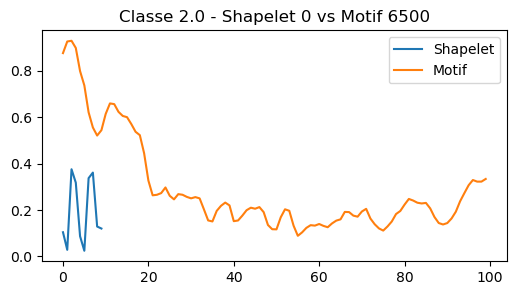

DTW distance to motif starting at 3901: nan


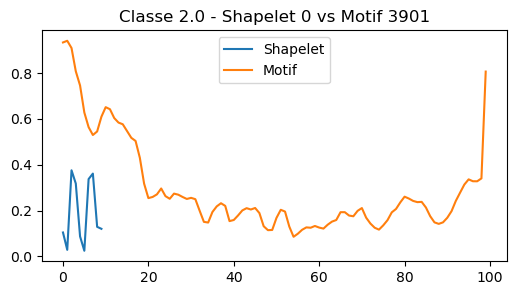


Shapelet 13:
DTW distance to motif starting at 3900: nan


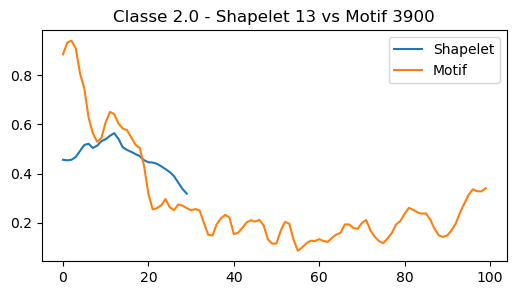

DTW distance to motif starting at 6500: nan


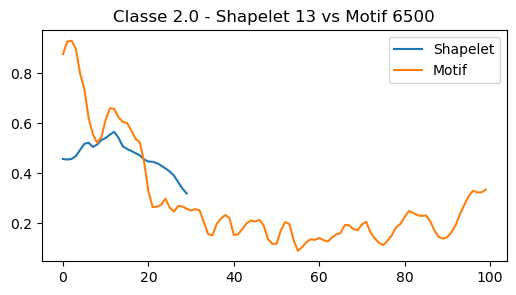

DTW distance to motif starting at 3901: nan


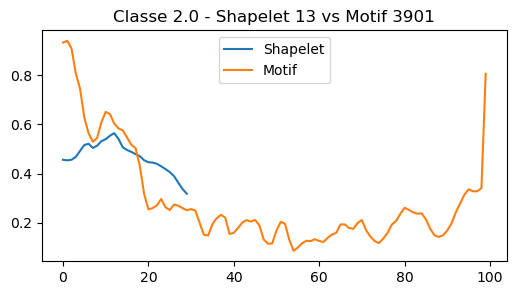


=== Classe 3.0 ===
Top 3 motif start indices (più frequenti): [13700, 8300, 13699]

Shapelet 19:
DTW distance to motif starting at 13700: nan


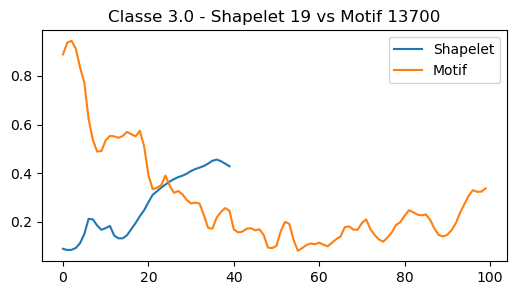

DTW distance to motif starting at 8300: nan


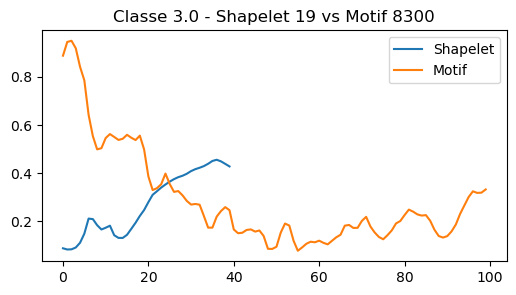

DTW distance to motif starting at 13699: nan


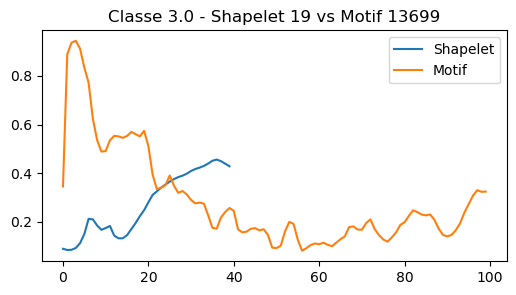


Shapelet 7:
DTW distance to motif starting at 13700: nan


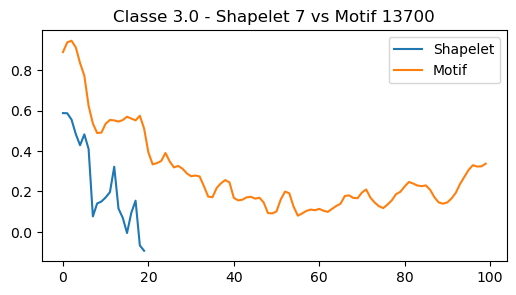

DTW distance to motif starting at 8300: nan


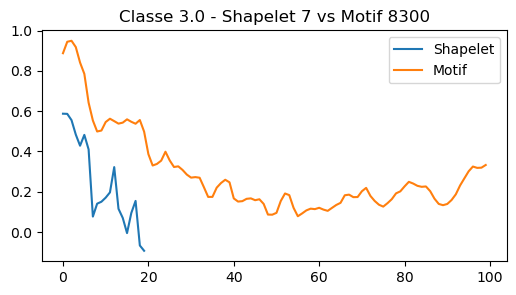

DTW distance to motif starting at 13699: nan


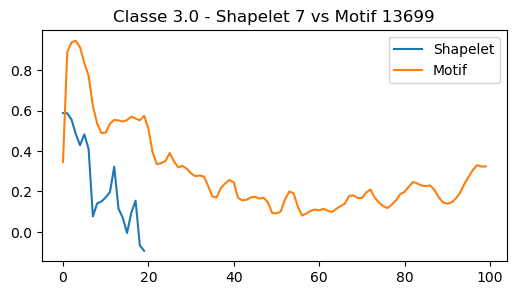


Shapelet 28:
DTW distance to motif starting at 13700: nan


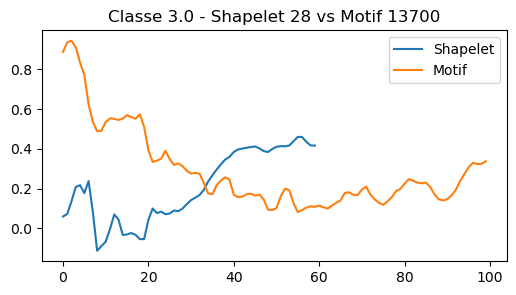

DTW distance to motif starting at 8300: nan


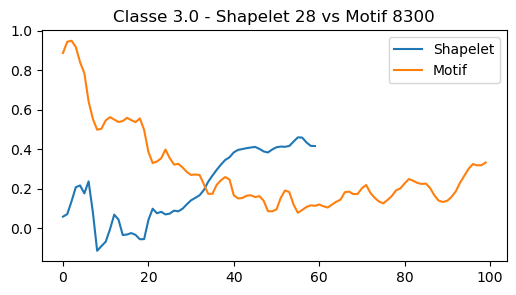

DTW distance to motif starting at 13699: nan


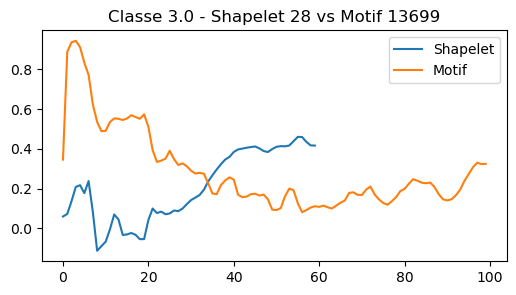


=== Classe 4.0 ===
Top 3 motif start indices (più frequenti): [18700, 24700, 24699]

Shapelet 44:
DTW distance to motif starting at 18700: 1.700


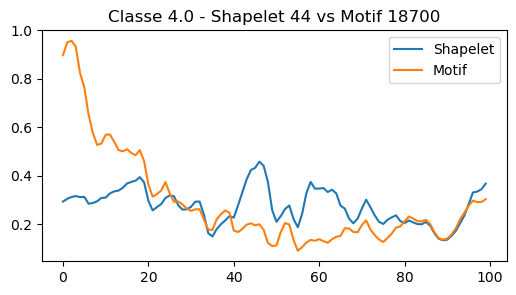

DTW distance to motif starting at 24700: 1.728


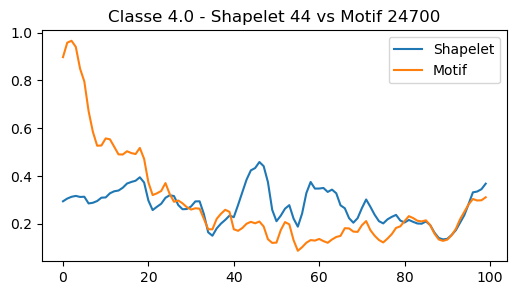

DTW distance to motif starting at 24699: 1.334


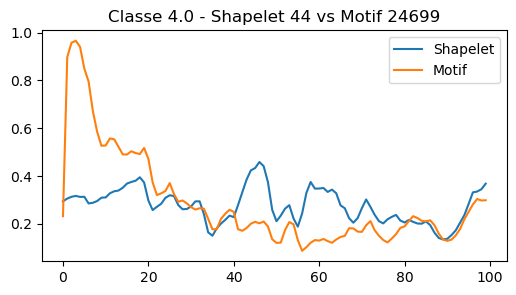


Shapelet 10:
DTW distance to motif starting at 18700: nan


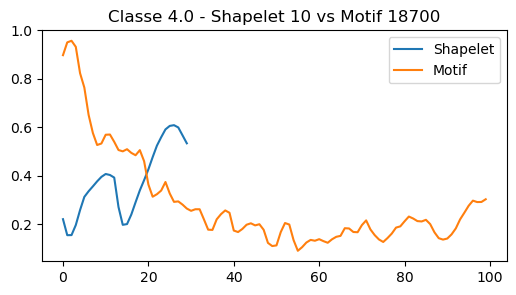

DTW distance to motif starting at 24700: nan


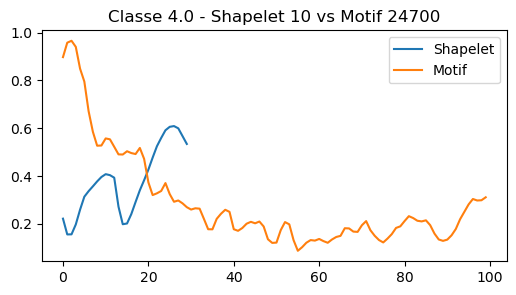

DTW distance to motif starting at 24699: nan


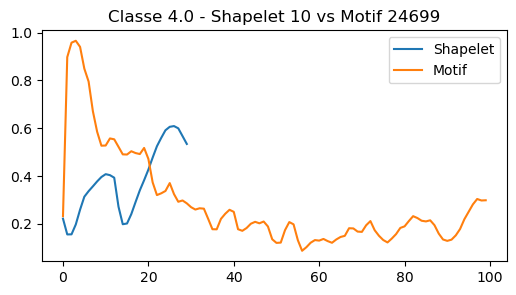


Shapelet 2:
DTW distance to motif starting at 18700: nan


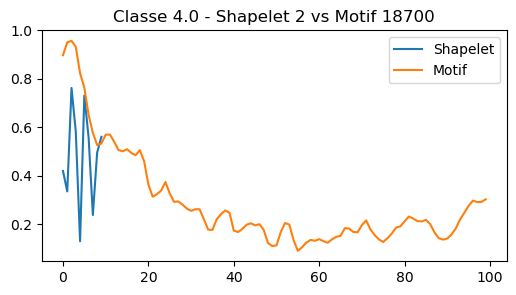

DTW distance to motif starting at 24700: nan


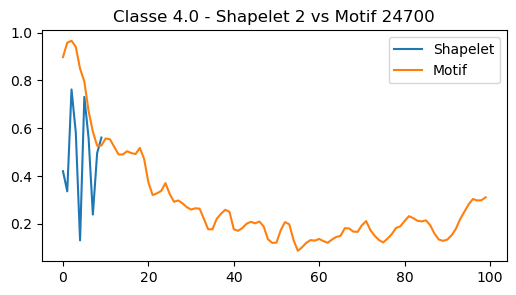

DTW distance to motif starting at 24699: nan


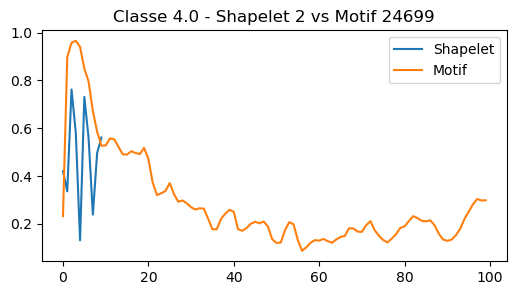

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy
from dtaidistance import dtw
from collections import Counter

# Supponiamo di avere già:
# X_train_scaled: array delle serie temporali scalate
# y_train: array delle etichette
# X_shp_train: distanze shapelet vs serie temporali
# shapelets: lista di shapelet estratte

def top_k_shapelets_per_class_func(X_shp_train, y_train, topk=3):
    """Calcola le top-k shapelet uniche per classe"""
    used_shapelets = set()
    all_topk = []
    for class_idx in np.unique(y_train):  # classi presenti
        mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) 
                               for i in range(X_shp_train.shape[1])])
        sorted_idx = np.argsort(mean_dists)
        
        topk_idx = []
        for idx in sorted_idx:
            if idx not in used_shapelets:
                topk_idx.append(idx)
                used_shapelets.add(idx)
            if len(topk_idx) >= topk:
                break
        all_topk.append(topk_idx)
    return all_topk

# Calcolo top 3 shapelet per classe
topk_shapelets_per_class = top_k_shapelets_per_class_func(X_shp_train, y_train, topk=3)

# Loop su ciascuna classe
for class_idx in np.unique(y_train):
    print(f"\n=== Classe {class_idx} ===")
    
    # Seleziona le serie della classe
    X_class = X_train_scaled[y_train == class_idx]
    
    # Concatenazione delle serie
    ts_concat = np.concatenate(X_class)
    
    # Lunghezza dei motif = lunghezza della shapelet più rappresentativa della classe
    motif_len = shapelets[int(topk_shapelets_per_class[int(class_idx)-1][0])].shape[0]
    
    # Calcolo matrix profile con STUMP
    mp = stumpy.stump(ts_concat, m=motif_len)
    
    # Trova i candidati motif (indici con distanza più bassa)
    candidate_idx = np.argsort(mp[:, 0])
    
    # Conta i motif più "frequenti" basandosi sulla vicinanza degli indici
    motif_occurrences = Counter()
    for idx in candidate_idx[:50]:  # consideriamo i 50 migliori
        motif_occurrences[idx] += 1
    
    # Prendi i top 3 motif più frequenti
    top3_motif_idx = [idx for idx, _ in motif_occurrences.most_common(3)]
    print(f"Top 3 motif start indices (più frequenti): {top3_motif_idx}")
    
    # Confronto DTW shapelet vs motif
    for shp_idx in topk_shapelets_per_class[int(class_idx)-1]:
        shp_idx = int(shp_idx)
        shp = shapelets[shp_idx]
        print(f"\nShapelet {shp_idx}:")
        
        for motif_start in top3_motif_idx:
            motif = ts_concat[motif_start:motif_start+motif_len]
            distance = dtw.distance(shp, motif)
            print(f"DTW distance to motif starting at {motif_start}: {distance:.3f}")
            
            # Plot confronto
            plt.figure(figsize=(6,3))
            plt.plot(shp, label='Shapelet')
            plt.plot(motif, label='Motif')
            plt.title(f"Classe {class_idx} - Shapelet {shp_idx} vs Motif {motif_start}")
            plt.legend()
            plt.show()


### MOTIFS

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matrixprofile import *
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [21]:
data = pd.read_csv('df_finale.csv')

In [22]:
data

,0,1,2,3,4,5,6,7,8,9,...,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Short,genre_Sport,genre_Thriller,genre_War,genre_Western,rating_encoded
0,3.203808,3.310528,3.080549,2.714583,2.409941,1.993775,1.583635,1.246871,0.796810,0.508554,...,0,0,0,1,0,0,0,0,0,4.0
1,1.641869,1.789420,1.837915,1.826346,1.841613,1.608536,1.322736,1.058922,0.766201,0.509104,...,0,0,1,0,0,0,0,0,0,4.0
2,2.146533,2.074483,1.922000,1.688202,1.367001,1.099541,0.879503,0.663925,0.466093,0.366285,...,0,0,0,0,0,0,0,0,0,4.0
3,1.244228,0.974971,0.792436,0.658828,0.110609,-0.230373,-0.290343,-0.352859,-0.421936,-0.490316,...,0,0,0,1,0,0,0,0,0,4.0
4,2.958126,2.791581,2.692438,2.631157,2.300224,2.052480,1.904554,1.740678,1.606702,1.489338,...,0,0,0,0,0,0,0,0,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,3.930861,3.678304,3.339795,2.963937,2.483528,2.027932,1.564115,1.153334,0.836055,0.641848,...,0,1,0,0,0,0,1,0,0,2.0
1130,2.917085,2.810270,2.618698,2.314326,2.073896,2.056742,1.890531,1.667496,1.459727,1.321335,...,0,0,0,0,0,0,0,0,0,2.0
1131,3.558092,3.264517,2.947922,2.588963,2.087472,1.656590,1.244943,0.928361,0.700896,0.570797,...,0,0,0,0,0,0,1,0,0,4.0
1132,3.468692,3.669017,3.510363,3.077339,2.725131,2.253547,1.699255,1.092181,0.427260,0.010953,...,0,0,0,0,0,0,0,0,0,4.0


In [23]:
df_timeseries = data.iloc[:, :100]
classes = data['rating_encoded']

In [24]:
# Seleziona prime 100 colonne + ultima colonna
df= data.iloc[:, list(range(100)) + [-1]]
df

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,rating_encoded
0,3.203808,3.310528,3.080549,2.714583,2.409941,1.993775,1.583635,1.246871,0.796810,0.508554,...,-0.773251,-0.785931,-0.803325,-0.819292,-0.826546,-0.800523,-0.780994,-0.758548,-0.731235,4.0
1,1.641869,1.789420,1.837915,1.826346,1.841613,1.608536,1.322736,1.058922,0.766201,0.509104,...,0.091804,-0.046413,-0.296589,-0.555315,-0.811598,-0.923964,-0.900554,-0.895424,-0.931546,4.0
2,2.146533,2.074483,1.922000,1.688202,1.367001,1.099541,0.879503,0.663925,0.466093,0.366285,...,-0.758995,-0.769806,-0.782269,-0.789811,-0.797837,-0.803927,-0.801292,-0.798581,-0.795879,4.0
3,1.244228,0.974971,0.792436,0.658828,0.110609,-0.230373,-0.290343,-0.352859,-0.421936,-0.490316,...,-0.366959,-0.498499,-0.525716,-0.548996,-0.568911,-0.587338,-0.602909,-0.612658,-0.613246,4.0
4,2.958126,2.791581,2.692438,2.631157,2.300224,2.052480,1.904554,1.740678,1.606702,1.489338,...,-0.646453,-0.645161,-0.645457,-0.647903,-0.651366,-0.656044,-0.661063,-0.665579,-0.668798,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,3.930861,3.678304,3.339795,2.963937,2.483528,2.027932,1.564115,1.153334,0.836055,0.641848,...,-0.582350,-0.584734,-0.588441,-0.591204,-0.592680,-0.593513,-0.593650,-0.593869,-0.594236,2.0
1130,2.917085,2.810270,2.618698,2.314326,2.073896,2.056742,1.890531,1.667496,1.459727,1.321335,...,-0.688884,-0.696743,-0.702418,-0.706121,-0.709908,-0.710889,-0.710866,-0.709265,-0.704758,2.0
1131,3.558092,3.264517,2.947922,2.588963,2.087472,1.656590,1.244943,0.928361,0.700896,0.570797,...,-0.547282,-0.579174,-0.602577,-0.644120,-0.707286,-0.765331,-0.802150,-0.828583,-0.841612,4.0
1132,3.468692,3.669017,3.510363,3.077339,2.725131,2.253547,1.699255,1.092181,0.427260,0.010953,...,-0.486256,-0.508885,-0.540992,-0.570104,-0.590912,-0.601979,-0.604438,-0.608394,-0.614915,4.0


In [25]:
def extract_motifs_matrix_profile(time_series, motif_length=7, max_motifs=5):
    """
    Estrae motifs usando matrixProfile con stomp
    """
    # Calcola matrix profile usando stomp
    profile = matrixProfile.stomp(time_series, motif_length)
    
    # Estrai motifs
    mtfs, motif_d = motifs.motifs(time_series, profile, max_motifs=max_motifs)
    
    # Estrai le subsequenze motif dalla time series
    extracted_motifs = []
    
    for motif_indices in mtfs:
        if len(motif_indices) > 0:
            # Prendi il primo indice del motif
            start_idx = motif_indices[0]
            motif_array = time_series[start_idx:start_idx + motif_length]
            extracted_motifs.append(motif_array)
    
    return extracted_motifs

In [26]:
def process_time_series_dataset(df, motif_length=7, max_motifs_per_series=5):
    """
    Processa un dataset di time series per estrarre motifs usando matrixProfile
    
    Parameters:
    df: DataFrame con prime 100 colonne come timestamps e class_label dopo
    motif_length: lunghezza dei motifs da estrarre (parametro m)
    max_motifs_per_series: numero massimo di motifs per serie
    """
    
    # Separa time series data e class labels
    time_series_cols = df_timeseries  # Prime 100 colonne
    class_col = classes  # Colonna 101 (class_label)
    
    motif_dataset = []
    
    for series_id in range(len(df)):
    # Estrai la time series dalla riga series_id
        time_series = df.iloc[series_id, :100].values  # Prime 100 colonne della riga
        class_label = df.iloc[series_id, 100]  # Colonna 101 della riga
       
       
        extracted_motifs = extract_motifs_matrix_profile(time_series, motif_length, 
                                                       max_motifs_per_series)
       
        for motif_array in extracted_motifs:
            motif_dict = {
                'motif': motif_array,
                'class': class_label,
                'series_id': series_id
            }
            motif_dataset.append(motif_dict)
    
    return motif_dataset

In [27]:
motifs_dataset = process_time_series_dataset(df, motif_length=7, max_motifs_per_series=5)

In [28]:
df_motifs = pd.DataFrame(motifs_dataset)
grouped = df_motifs.groupby('class')

In [29]:
from dtaidistance import dtw

def avg_similarity(motif, motif_list):
    return np.mean([dtw.distance(motif, other) for other in motif_list])

In [30]:
top_motifs = {}
for cls, group in grouped:
    motifs = group['motif'].tolist()
    scores = [avg_similarity(m, motifs) for m in motifs]
    top_indices = np.argsort(scores)[:3]
    top_motifs[cls] = top_indices

In [31]:
top_motifs

{0.0: array([ 9,  0, 19], dtype=int64),
 1.0: array([427, 348, 260], dtype=int64),
 2.0: array([981, 787, 156], dtype=int64),
 3.0: array([723, 290, 195], dtype=int64),
 4.0: array([1072, 1293,  403], dtype=int64)}

In [32]:
import numpy as np
from tslearn.metrics import dtw
from scipy.signal import resample

# --- Funzione di utilità per resampling ---
def resample_to_same_length(a, b):
    if len(a) < len(b):
        a_res = resample(a, len(b))
        return a_res, b
    elif len(b) < len(a):
        b_res = resample(b, len(a))
        return a, b_res
    else:
        return a, b

# --- Confronto top-3 motifs (già selezionati) vs shapelets ---
def compare_top3_indices_to_shapelets(top_motifs_indices, top_shapelets, shapelet_model, motif_dataset):
    results = {}
    learned_shapelets = shapelet_model.shapelets_

    for cls, indices in top_motifs_indices.items():
        # Recupera i motifs dai loro indici
        motifs = [motif_dataset[idx]['motif'] for idx in indices]
        
        # Shapelets top-k per classe
        shapelet_idxs = top_shapelets[cls]
        shps = [learned_shapelets[i].ravel() for i in shapelet_idxs]

        sim_matrix_dtw = np.zeros((len(motifs), len(shps)))
        sim_matrix_corr = np.zeros((len(motifs), len(shps)))

        for i, motif in enumerate(motifs):
            for j, shp in enumerate(shps):
                # DTW
                sim_matrix_dtw[i, j] = dtw(motif, shp)

                # Correlazione con resampling
                m_res, s_res = resample_to_same_length(motif, shp)
                m_res -= np.mean(m_res)
                s_res -= np.mean(s_res)
                denom = (np.linalg.norm(m_res) * np.linalg.norm(s_res))
                corr = np.dot(m_res, s_res) / denom if denom > 0 else 0
                sim_matrix_corr[i, j] = corr

        results[cls] = {
            "dtw": sim_matrix_dtw,
            "correlation": sim_matrix_corr,
            "motifs_indices": indices,
            "shapelet_idxs": shapelet_idxs
        }

    return results

# --- Report leggibile ---
def print_comparison_report(results):
    for cls, sims in results.items():
        print(f"\nClasse {cls}:")
        dtw_mat = sims["dtw"]
        corr_mat = sims["correlation"]
        motifs_indices = sims["motifs_indices"]
        shapelet_idxs = sims["shapelet_idxs"]

        for i, motif_idx in enumerate(motifs_indices):
            best_j_dtw = np.argmin(dtw_mat[i])
            best_j_corr = np.argmax(corr_mat[i])
            print(f" Motif {motif_idx}:")
            print(f"   -> più simile a Shapelet {shapelet_idxs[best_j_dtw]} con DTW={dtw_mat[i,best_j_dtw]:.4f}")
            print(f"   -> più correlato a Shapelet {shapelet_idxs[best_j_corr]} con Corr={corr_mat[i,best_j_corr]:.4f}")


In [33]:
results = compare_top3_indices_to_shapelets(top_motifs, result, shp_model, motifs_dataset)

# Stampa report
print_comparison_report(results)


Classe 0.0:
 Motif 9:
   -> più simile a Shapelet 0 con DTW=2.0307
   -> più correlato a Shapelet 15 con Corr=0.8911
 Motif 0:
   -> più simile a Shapelet 0 con DTW=7.5835
   -> più correlato a Shapelet 15 con Corr=0.8446
 Motif 19:
   -> più simile a Shapelet 0 con DTW=5.7619
   -> più correlato a Shapelet 15 con Corr=0.8981

Classe 1.0:
 Motif 427:
   -> più simile a Shapelet 15 con DTW=4.4849
   -> più correlato a Shapelet 15 con Corr=0.8963
 Motif 348:
   -> più simile a Shapelet 0 con DTW=0.5968
   -> più correlato a Shapelet 0 con Corr=-0.7186
 Motif 260:
   -> più simile a Shapelet 15 con DTW=0.5138
   -> più correlato a Shapelet 15 con Corr=0.8900

Classe 2.0:
 Motif 981:
   -> più simile a Shapelet 5 con DTW=1.0840
   -> più correlato a Shapelet 15 con Corr=0.8892
 Motif 787:
   -> più simile a Shapelet 15 con DTW=1.5411
   -> più correlato a Shapelet 15 con Corr=0.8926
 Motif 156:
   -> più simile a Shapelet 5 con DTW=0.8037
   -> più correlato a Shapelet 5 con Corr=0.8168



### approccio 2

In [34]:
X = data.iloc[:, list(range(100))]
y = data["rating_encoded"]

In [35]:
df_timestamp_class = data.iloc[:, list(range(100)) + [-1]]

In [ ]:
# import numpy as np
# from tslearn.metrics import dtw
# from collections import defaultdict

# # --- Calcolo distanza media motifs ↔ classi ---
# def motif_class_profiles(motif_dataset, X, y, metric="dtw"):
#     """
#     Calcola per ciascun motif un profilo di distanza media per classe.
    
#     Parameters
#     ----------
#     motif_dataset : list of dict
#         Ogni dict ha 'motif', 'class', 'series_id'
#     X : ndarray shape (n_samples, series_length)
#         Serie temporali originali
#     y : ndarray shape (n_samples,)
#         Etichette di classe
#     metric : str
#         'dtw' oppure 'corr' per similarità
    
#     Returns
#     -------
#     profiles : dict
#         motif_idx -> {classe: distanza_media}
#     """
#     classes = np.unique(y)
#     profiles = {}
    
#     for idx, motif_entry in enumerate(motif_dataset):
#         motif = motif_entry['motif']
#         profiles[idx] = {}
        
#         for c in classes:
#             # Seleziona serie della classe c
#             class_series = X[y == c]
            
#             dists = []
#             for ts in class_series:
#                 # Prendo finestre della stessa lunghezza del motif
#                 subseq = ts[:len(motif)]  # semplice, ma puoi fare sliding window
#                 if metric == "dtw":
#                     d = dtw(motif, subseq)
#                 else:
#                     # correlazione
#                     denom = (np.linalg.norm(motif) * np.linalg.norm(subseq))
#                     d = np.dot(motif, subseq) / denom if denom > 0 else 0
#                     d = 1 - d  # trasformo in distanza
#                 dists.append(d)
            
#             profiles[idx][c] = np.mean(dists)
    
#     return profiles


# # --- Ordina motifs per classe ---
# def top_motifs_by_class(profiles, top_k=3):
#     """
#     Ordina motifs in base alla distanza media per ciascuna classe.
#     """
#     classes = list(next(iter(profiles.values())).keys())
#     top = {}
#     for c in classes:
#         # prendi tuple (motif_idx, distanza_media)
#         motif_scores = [(m_idx, d[c]) for m_idx, d in profiles.items()]
#         # ordina crescente (min distanza = più vicino alla classe)
#         motif_scores = sorted(motif_scores, key=lambda x: x[1])
#         top[c] = motif_scores[:top_k]
#     return top


# # --- Matching motifs vs shapelets ---
# def match_motifs_shapelets(top_motifs, top_shapelets):
#     """
#     Confronta i ranking motifs vs shapelets per ogni classe.
    
#     top_motifs: dict {classe -> [(motif_idx, dist), ...]}
#     top_shapelets: dict {classe -> [shapelet_idx, ...]} già calcolati
    
#     Output: report di matching
#     """
#     report = {}
#     for c in top_motifs:
#         motif_list = [m for m, _ in top_motifs[c]]
#         shapelet_list = top_shapelets.get(c, [])
        
#         overlap = set(motif_list).intersection(set(shapelet_list))
#         report[c] = {
#             "motifs_top": motif_list,
#             "shapelets_top": shapelet_list,
#             "overlap": list(overlap)
#         }
#     return report


In [ ]:
# # 1. Calcola profili motifs ↔ classi
# profiles = motif_class_profiles(motifs_dataset, X, y, metric="dtw")

# # 2. Trova i top motifs più vicini per ciascuna classe
# top_motifs = top_motifs_by_class(profiles, top_k=3)

# # 3. Confronta con i top shapelets già noti
# report = match_motifs_shapelets(top_motifs, results)

# # 4. Stampa risultati
# for c, r in report.items():
#     print(f"\nClasse {c}:")
#     print(f" Top motifs: {r['motifs_top']}")
#     print(f" Top shapelets: {r['shapelets_top']}")
#     print(f" Overlap: {r['overlap']}")

### codice luca in chat

In [ ]:
# from dtaidistance import dtw

# # Dizionari con top 3 shapelet e motif per ogni classe
# shapelets_by_class = results
 
# motifs_by_class = top_motifs
 
# # Funzione per contare le occorrenze con DTW
# def count_dtw_matches(series, pattern, threshold):
#     count = 0
#     plen = len(pattern)
#     for i in range(len(series) - plen + 1):
#         window = series[i:i+plen]
#         dist = dtw.distance(window, pattern)
#         if dist < threshold:
#             count += 1
#     return count
 
# # Analisi per classe
# analysis = {}
 
# for cls in shapelets_by_class:
#     shapelets = shapelets_by_class[cls]
#     motifs = motifs_by_class[cls]
#     # Seleziona solo le serie temporali della classe corrente
#     mask = df_timestamp_class == cls
#     df_cls = df[mask]
#     shapelet_counts = []
#     motif_counts = []
 
#     for _, row in df_cls.iterrows():
#         series = row.values.astype(float)
#         s_counts = [count_dtw_matches(series, s, threshold=10.0) for s in shapelets]
#         m_counts = [count_dtw_matches(series, m, threshold=10.0) for m in motifs]
#         shapelet_counts.append(s_counts)
#         motif_counts.append(m_counts)
 
#     analysis[cls] = {
#         'shapelet_counts': np.array(shapelet_counts),
#         'motif_counts': np.array(motif_counts)
#     }
 
# # Visualizza i risultati per una classe
# for cls in analysis:
#     print(f"\n🔍 Classe: {cls}")
#     print("📊 Occorrenze shapelet:")
#     print(analysis[cls]['shapelet_counts'])
#     print("🔗 Occorrenze motif:")
#     print(analysis[cls]['motif_counts'])

In [36]:
import numpy as np

motif_len = 7  # lunghezza fissata del motif

motifs_by_class_real = {
    cls: [np.array(motifs_dataset[idx]["motif"], dtype=float) for idx in idxs]
    for cls, idxs in top_motifs.items()
}
motifs_by_class_real

{0.0: [array([ 0.52269398,  0.44888558,  0.32348626,  0.16000622,  0.03138061,
         -0.05886774, -0.10247116]),
  array([3.20380752, 3.31052783, 3.08054906, 2.71458332, 2.40994107,
         1.99377548, 1.58363534]),
  array([3.20689624, 2.86544761, 2.36223283, 1.91464684, 1.49474994,
         1.11874235, 0.78176021])],
 1.0: [array([2.82709373, 2.42939925, 1.9642509 , 1.50275742, 0.9839896 ,
         0.56345998, 0.27856069]),
  array([-0.2666326 , -0.23598624, -0.1691162 , -0.06187982,  0.09525527,
          0.20630301,  0.25842654]),
  array([ 0.2358561 ,  0.17183695,  0.07958548, -0.04799788, -0.21095908,
         -0.30961364, -0.35310316])],
 2.0: [array([ 0.06952303, -0.02491911, -0.17067132, -0.38639947, -0.5621544 ,
         -0.69860523, -0.78021137]),
  array([ 1.28215271,  1.05506351,  0.73612995,  0.31132028, -0.04478522,
         -0.2991001 , -0.44626125]),
  array([-0.26802007, -0.2204929 , -0.14067699,  0.01778415,  0.28281164,
          0.49237371,  0.63823317])],
 3.0

In [37]:
import numpy as np

# Supponiamo che il modello sia chiamato shp_model
# e che abbia un attributo shapelets_ con dentro le shapelet stesse
all_shapelets = shp_model.shapelets_

# Ora costruiamo lo stesso dizionario "real" come per i motifs
shapelets_by_class_real = {
    cls: [np.array(all_shapelets[idx], dtype=float) for idx in idxs]
    for cls, idxs in result.items()
}
shapelets_by_class_real

{0.0: [array([[-0.48711625],
         [-0.45971254],
         [-0.43719172],
         [-0.49496168],
         [-0.52197438],
         [-0.54215765],
         [-0.54671437],
         [-0.52754575],
         [-0.52494168],
         [-0.52008039]]),
  array([[-0.17956746],
         [-0.22062887],
         [-0.25208402],
         [-0.25760216],
         [-0.24201898],
         [-0.2898134 ],
         [-0.36342791],
         [-0.39178523],
         [-0.3877255 ],
         [-0.38721642],
         [-0.38904947],
         [-0.39183995],
         [-0.39649421],
         [-0.40839481],
         [-0.42005578],
         [-0.43869305],
         [-0.4559195 ],
         [-0.37233531],
         [-0.36813194],
         [-0.38711154],
         [-0.40392742],
         [-0.42072502],
         [-0.45438826],
         [-0.49948442],
         [-0.54810786],
         [-0.57396752],
         [-0.58553803],
         [-0.59474671],
         [-0.61937737],
         [-0.637986  ],
         [-0.59320927],
         

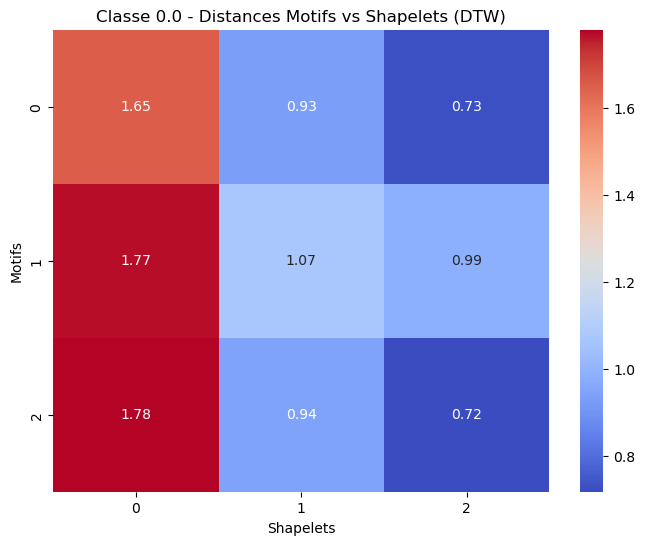

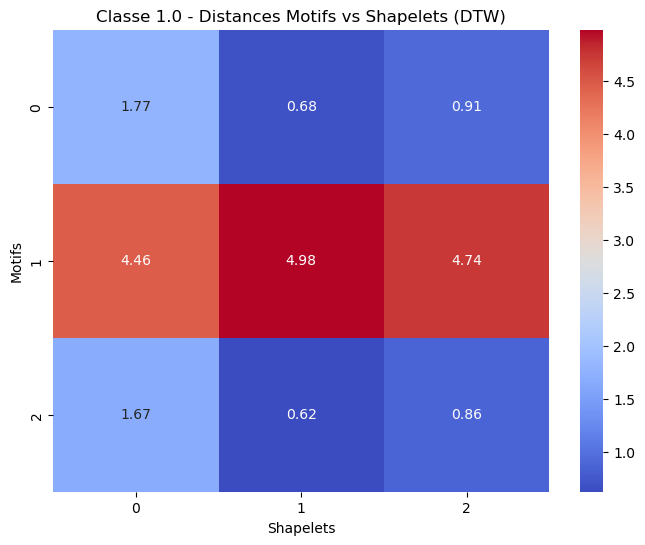

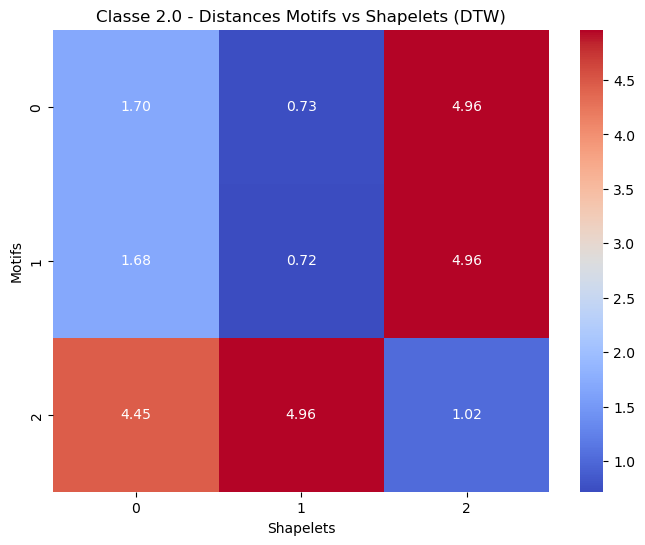

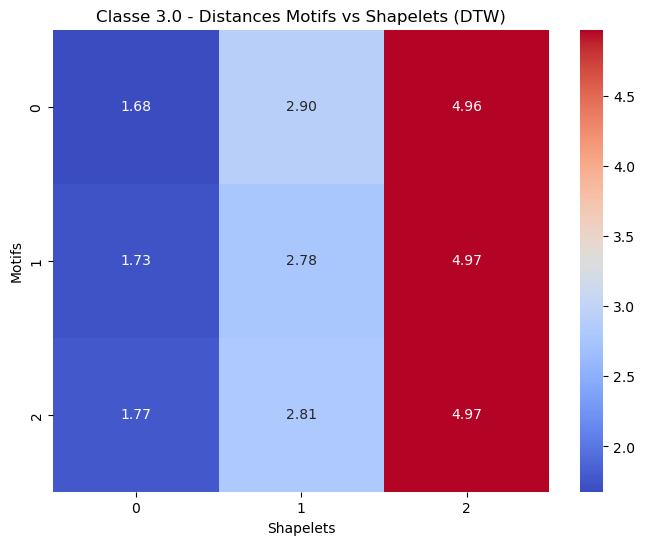

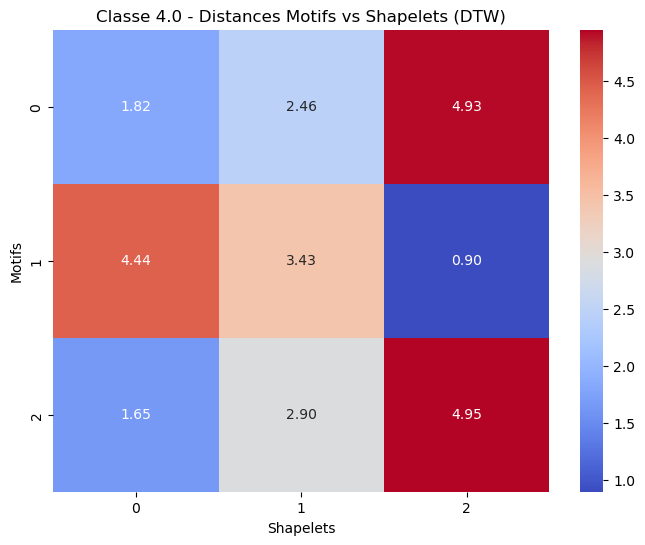

In [38]:
import numpy as np
from dtaidistance import dtw
from scipy.signal import resample
import seaborn as sns
import matplotlib.pyplot as plt

# Funzione di normalizzazione z-score
def z_normalize(ts):
    ts = np.array(ts, dtype=float)
    return (ts - ts.mean()) / ts.std()

# Funzione per confrontare motifs vs shapelets di una classe
def compare_class_motifs_shapelets(motifs, shapelets, method="dtw"):
    """
    motifs: lista di array 1D
    shapelets: lista di array 2D (colonna), viene appiattita
    method: "euclidean" o "dtw"
    """
    results = np.zeros((len(motifs), len(shapelets)))
    
    for i, m in enumerate(motifs):
        m_norm = z_normalize(m)
        for j, s in enumerate(shapelets):
            s_arr = z_normalize(s.ravel())
            
            # Resample shapelet se lunghezza diversa
            if len(s_arr) != len(m_norm):
                s_arr = resample(s_arr, len(m_norm))
            
            # Calcolo distanza/similarità
            if method == "euclidean":
                dist = np.linalg.norm(m_norm - s_arr)
            elif method == "dtw":
                dist = dtw.distance(m_norm, s_arr)
            else:
                raise ValueError("Metodo non supportato")
            
            results[i,j] = dist
    return results

# Ciclo su tutte le classi e creo heatmap
for cls in motifs_by_class_real.keys():
    motifs = motifs_by_class_real[cls]
    shapelets = shapelets_by_class_real[cls]
    
    dist_matrix = compare_class_motifs_shapelets(motifs, shapelets, method="dtw")
    
    plt.figure(figsize=(8,6))
    sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Classe {cls} - Distances Motifs vs Shapelets (DTW)")
    plt.xlabel("Shapelets")
    plt.ylabel("Motifs")
    plt.show()


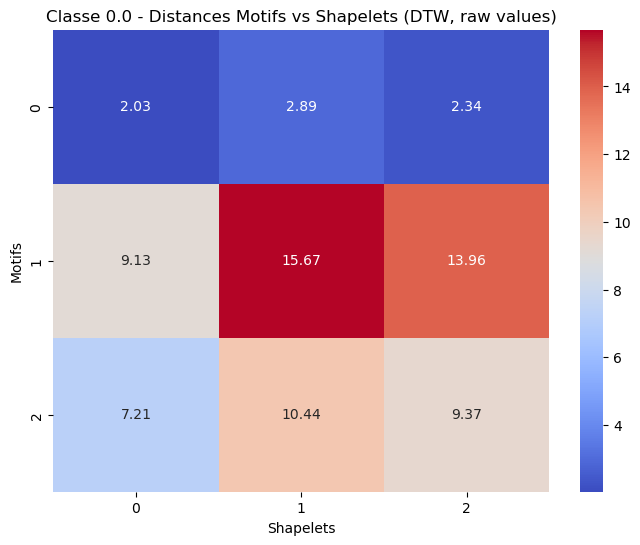

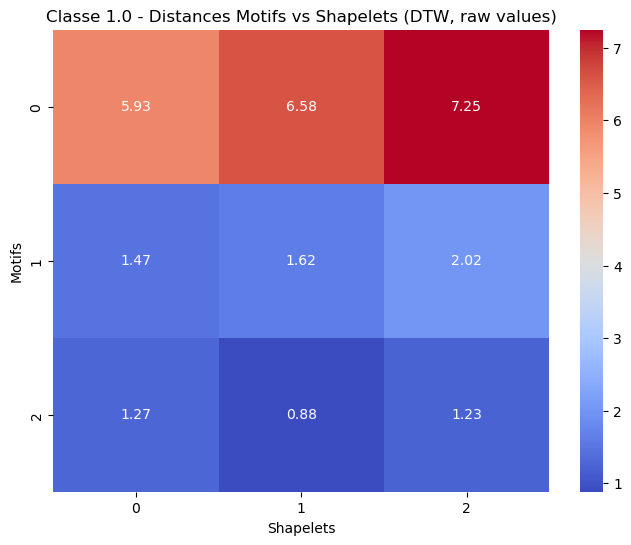

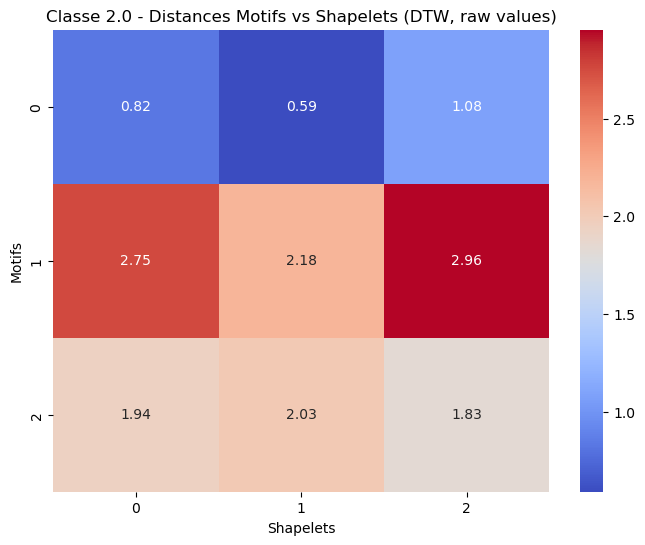

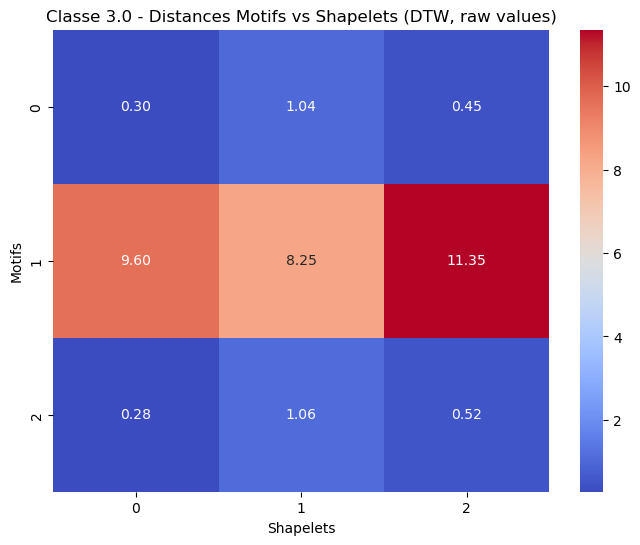

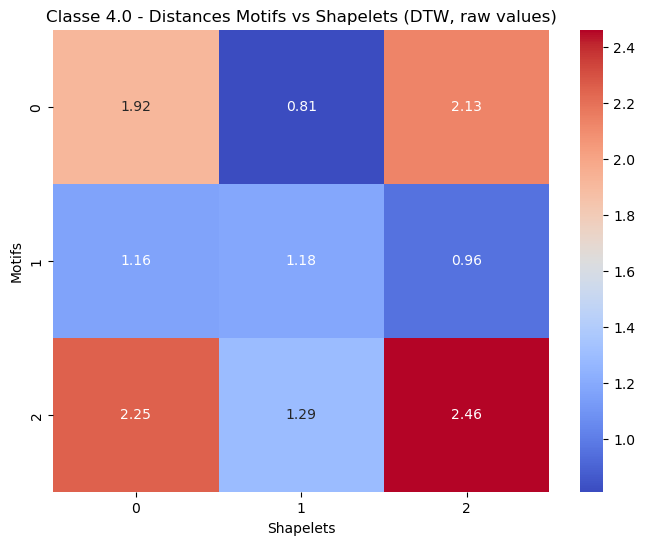

In [42]:
import numpy as np
from dtaidistance import dtw
from scipy.signal import resample
import seaborn as sns
import matplotlib.pyplot as plt

def compare_class_motifs_shapelets_raw(motifs, shapelets, method="dtw"):
    """
    Confronta motifs e shapelets senza normalizzazione.
    motifs: lista di array 1D
    shapelets: lista di array 2D (colonna)
    method: "euclidean" o "dtw"
    """
    results = np.zeros((len(motifs), len(shapelets)))
    
    for i, m in enumerate(motifs):
        for j, s in enumerate(shapelets):
            s_arr = s.ravel()
            
            # Resample shapelet se lunghezza diversa
            if method == "dtw":
                dist = dtw.distance(m, s_arr)
            else:
                raise ValueError("Metodo non supportato")
            
            results[i,j] = dist
    return results

# Ciclo su tutte le classi e creo heatmap
for cls in motifs_by_class_real.keys():
    motifs = motifs_by_class_real[cls]
    shapelets = shapelets_by_class_real[cls]
    
    dist_matrix = compare_class_motifs_shapelets_raw(motifs, shapelets, method="dtw")
    
    plt.figure(figsize=(8,6))
    sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="coolwarm")  # palette modificabile
    plt.title(f"Classe {cls} - Distances Motifs vs Shapelets (DTW, raw values)")
    plt.xlabel("Shapelets")
    plt.ylabel("Motifs")
    plt.show()


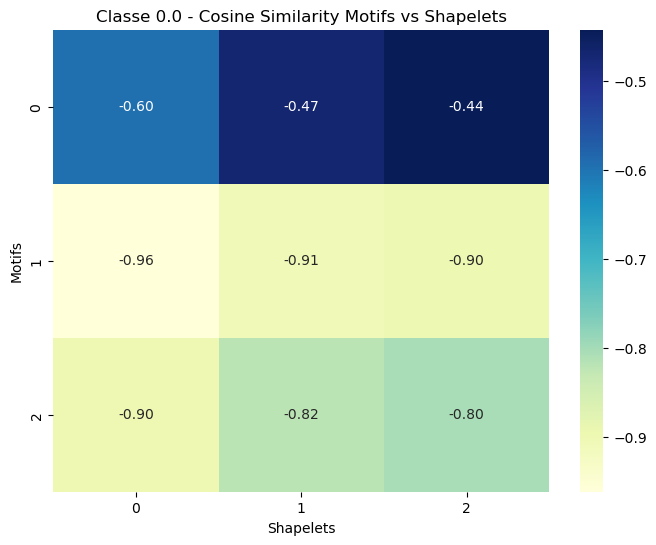

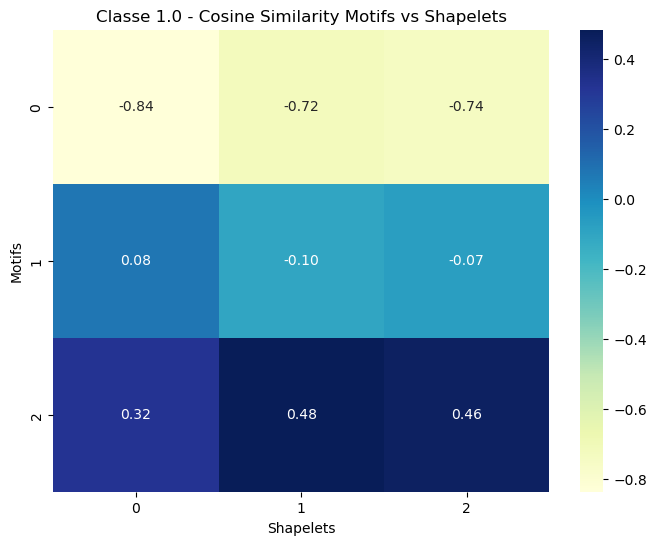

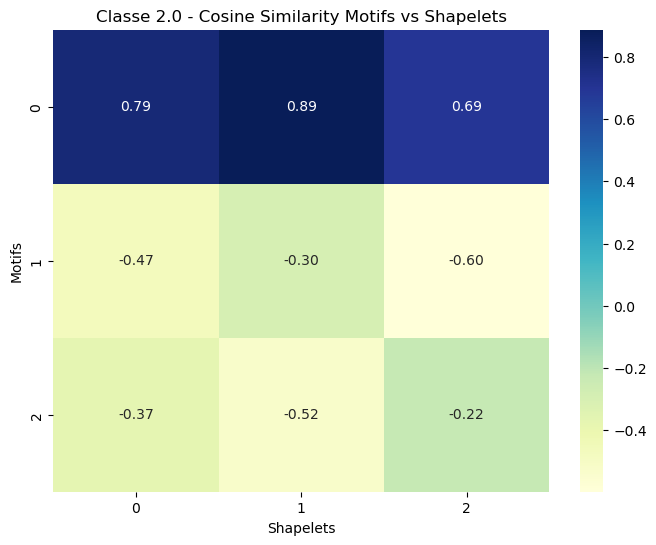

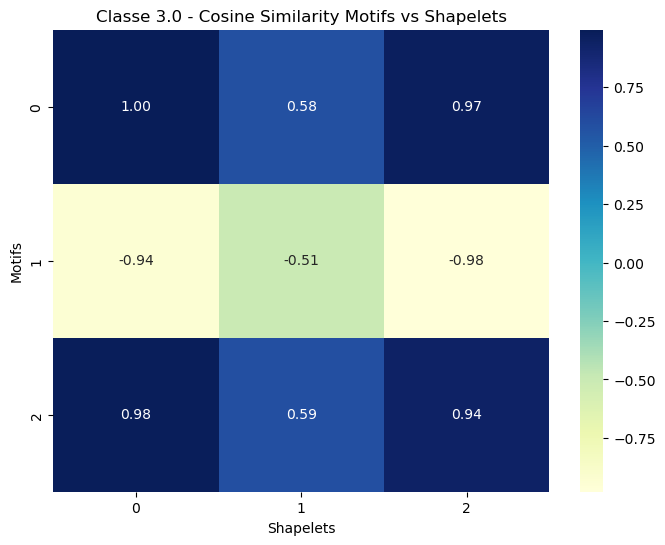

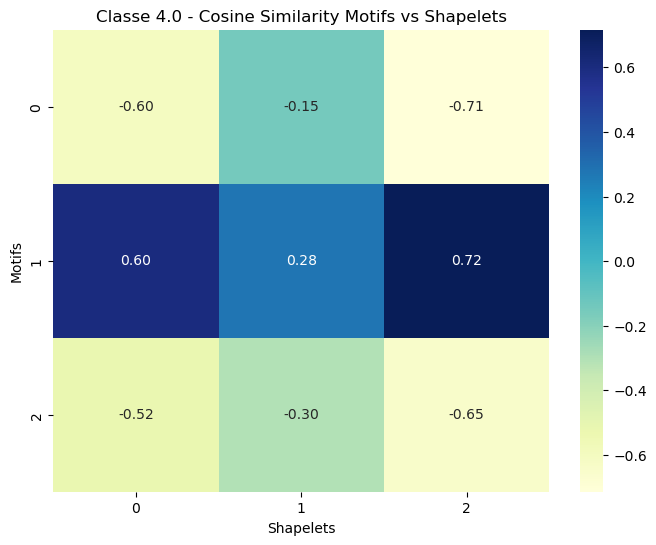

In [41]:
import numpy as np
from scipy.signal import resample
import seaborn as sns
import matplotlib.pyplot as plt

def cosine_similarity(a, b):
    """Calcola la similarità coseno tra due vettori 1D."""
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    dot = np.dot(a, b)
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    return dot / norm if norm != 0 else 0.0

def compare_class_motifs_shapelets_cosine(motifs, shapelets):
    """
    Confronta motifs e shapelets usando la Cosine Similarity.
    Restituisce una matrice motifs x shapelets con valori [0,1]
    """
    results = np.zeros((len(motifs), len(shapelets)))
    
    for i, m in enumerate(motifs):
        for j, s in enumerate(shapelets):
            s_arr = s.ravel()
            
            # Resample shapelet se lunghezza diversa
            if len(s_arr) != len(m):
                s_arr = resample(s_arr, len(m))
            
            # Calcola cosine similarity
            results[i,j] = cosine_similarity(m, s_arr)
    
    return results

# Ciclo su tutte le classi e creo heatmap
for cls in motifs_by_class_real.keys():
    motifs = motifs_by_class_real[cls]
    shapelets = shapelets_by_class_real[cls]
    
    sim_matrix = compare_class_motifs_shapelets_cosine(motifs, shapelets)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlGnBu")  # palette diversa
    plt.title(f"Classe {cls} - Cosine Similarity Motifs vs Shapelets")
    plt.xlabel("Shapelets")
    plt.ylabel("Motifs")
    plt.show()


In [ ]:
aligner = AlignerDtwNumba()
aligner.fit([pd.DataFrame(ts1), pd.DataFrame(ts2)])
alignments = aligner.get_alignment()
aligned_1, aligned_2 = aligner.get_aligned()